In [1]:
#Modules
import os
import numpy as np 
import pandas as pd
import random
from scipy.optimize import curve_fit
from scipy.optimize import bisect
from scipy.interpolate import UnivariateSpline as spline
import matplotlib.pyplot as plt
from uncertainties import ufloat , unumpy
from ase.io import read, write, iread
from ase import Atoms
from ase.units import Bohr , Rydberg , Hartree , GPa , kB
#Plot parameters
plt.rcParams["figure.figsize"] = (8,6)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
plt.rcParams['font.size'] = 30  # font size
plt.rcParams['xtick.direction'] = 'in' # x-axis inside:(‘in’), outside:(‘out’), both:(‘inout’)
plt.rcParams['ytick.direction'] = 'in' # y-axis inside:(‘in’), outside:(‘out’), both:(‘inout’)
plt.rcParams['xtick.major.width'] = 1.0 # x, major
plt.rcParams['ytick.major.width'] = 1.0 # y, major
plt.rcParams['axes.linewidth'] = 1.5 # edge, linewidth
from mpl_toolkits.axes_grid1.inset_locator import (inset_axes, InsetPosition,
                                                  mark_inset)

## Utility functions

In [2]:
#GENERAL UTILITY

#rho in g / cm**3
#rs in a.u.

atomic_mass_to_kg=1.66057*10**-27

def rho_from_rs(rs):
    convert = 22.570164502267158 / ( 4 * np.pi / 3.0 )
    return convert / rs**3 



def rs_from_rho(rho): 
    convert = 22.570164502267158 / ( 4 * np.pi / 3.0 )
    return np.cbrt(convert / rho )


def rs_from_n(rho): 
    convert = 1 / ( 4 * np.pi / 3.0 )
    return np.cbrt(convert / rho )


#rs_from_n(128/16.247861**3)
#print(1 / ( 4 * np.pi * 1.80**3 / 3))

Here we define some functions that extract information from output files of the md code ( that have already been analized). As an input you have to specify:
- Temperature of the simulations (required). This is used to find all the files corresponding to the given temperature 
- directory where the relevants file are (default './')
- rs value (required only if you want to see the history of thermodyamic quantities of one simulation)

Use "plot" functions to visualize the data

In [3]:
def get_average(T,root = './'):
    all_files = [f for f in os.listdir(os.path.join(root)) if os.path.isfile(os.path.join(root + f))]
    rs_list = []
    kin = []
    kin_err = []
    pot = []
    pot_err = []
    E = []
    E_err = []
    temperature = []
    temperature_err = []
    pressure = []
    pressure_err = []
    thermodata = {}
    for filename in all_files: 
        if f'out{T}' in filename: 
            rs = float(filename.replace(f'out{T}K-',''))
            rs_list.append(rs)
    #get average thermodynamic quantities 
    rs_list.sort()
    for rs in rs_list:
        filename = f'out{T}K-{rs:.2f}'
        with open(os.path.join(root + filename),'r') as file_out: 
            for l in file_out.readlines():
                if 'Average kinetic energy per particle' in l:
                    data = [float(x.strip('\n')) for x in l.strip('Average kinetic energy per particle =').split(' ') if (x != '+/-' and x!= '')]
                    kin.append(data[0])
                    kin_err.append(data[1])
                if 'Average potential energy per particle' in l:
                    data = [float(x.strip('\n')) for x in l.strip('Average potential energy per particle =').split(' ') if (x != '+/-' and x!= '')]
                    pot.append(data[0])
                    pot_err.append(data[1])
                if 'Average energy (kin + pot) per particle' in l:
                    data = [float(x.strip('\n')) for x in l.strip('Average energy (kin + pot) per particle =').split(' ') if (x != '+/-' and x!= '')]
                    E.append(data[0])
                    E_err.append(data[1])
                if 'Average temperature' in l:
                    data = [float(x.strip('\n')) for x in l.strip('Average temperature =').split(' ') if (x != '+/-' and x!= '')]
                    temperature.append(data[0])
                    temperature_err.append(data[1])
                if 'Average pressure' in l:
                    data = [float(x.strip('\n')) for x in l.strip('Average pressure =').split(' ') if (x != '+/-' and x!= '')]
                    pressure.append(data[0]*2.9421015697E04)
                    pressure_err.append(data[1]*2.9421015697E04)
    thermodata = {'Kinetic Energy' : (np.array(kin), np.array(kin_err)) , 'Potential Energy' : (np.array(pot), np.array(pot_err)), \
                 'E' : (np.array(E), np.array(E_err)) , 'Temperature' : (np.array(temperature), np.array(temperature_err)), \
                 'Pressure' : (np.array(pressure), np.array(pressure_err)) , 'rs' : np.array(rs_list)}
    return thermodata 

def get_instant(T,rs,root = './'):
    all_files = [f for f in os.listdir(os.path.join(root)) if os.path.isfile(os.path.join(root + f))]
    for filename in all_files: 
        if f'thermo{T}K' in filename: 
            rs_file = float(filename.replace(f'thermo{T}K-', '').replace('.dat', ''))
            if rs_file == rs: 
                file = os.path.join(root +filename)
                thermodata = {}
                with open(file,'r') as f:
                    time = np.loadtxt(f,usecols = (1))
                    thermodata['Time'] = time
                with open(file,'r') as f:
                    potential = np.loadtxt(f,usecols = (3))
                    thermodata['Potential Energy'] = potential
                with open(file,'r') as f:
                    kin = np.loadtxt(f,usecols = (2))
                    thermodata['Kinetic Energy'] = kin
                with open(file,'r') as f:
                    tot_en = np.loadtxt(f,usecols = (4))
                    thermodata['E'] = tot_en
                with open(file,'r') as f:
                    temperature = np.loadtxt(f,usecols = (5))
                    thermodata['Temperature'] = temperature
                with open(file,'r') as f:
                    heff = np.loadtxt(f,usecols = (6))  
                    thermodata['E_eff'] = heff
                with open(file,'r') as f:
                    press = 2.9421015697E04 * np.loadtxt(f,usecols = (7))  
                    thermodata['Pressure'] = press
    return thermodata

def get_units():
    units = {'Time' : '( a.u. )' ,  'Potential Energy' : '( Ha )', 'Kinetic Energy': '( Ha )',\
            'E' : '( Ha )', 'Temperature' : '( K )', 'E_eff' : '( Ha )', 'Pressure' : '( GPa )' }
    return units


def plot_thermo(T,rs,root = './' , key = 'E', col = 'k'):
    thermodata = get_instant(T,rs,root)
    units = get_units()
    plt.xlabel('Time (fs)')
    plt.ylabel(key + ' ' + units[key])
    plt.title(f' rs = {rs} , T = {T} K ')
    plt.plot(thermodata['Time']*0.02418884254, thermodata[key] , color = col)

def plot_average(T,root = './' , key = 'Pressure' , col = 'k'):
    thermodata = get_average(T,root)
    units = get_units() 
    plt.xlabel(r'Wigner-Seitz radius $rs$')
    plt.ylabel(key + ' ' + units[key])
    plt.errorbar(thermodata['rs'] , thermodata[key][0] , yerr = thermodata[key][1] , fmt = '*' , ms = 12,color = 'k')
    plt.plot(thermodata['rs'] , thermodata[key][0], color = col)

This defines the Hugoniot function

In [4]:
def hugoniot(T,root = './',e0=-0.583725,rho0 = 0.167): 
    thermodata = get_average(T, root)
    e_per_atom = np.array( [ ufloat(x,y) for x, y in zip(thermodata['E'][0],thermodata['E'][1])])
    pressure = np.array( [ ufloat(x,y) for x, y in zip(thermodata['Pressure'][0],thermodata['Pressure'][1])])
    rs = thermodata['rs']
    n_points = np.size(rs)
    e0 = e0 * np.ones(n_points)
    rs0 = rs_from_rho(rho0) * np.ones(n_points)
    P0 = 1.24E-4 * np.ones(n_points) 
    H = e_per_atom - e0 + 2 * np.pi / 3 * (rs**3 - rs0**3) * (pressure + P0) / 2.9421015697E04
    return (rs, H )

This function finds the Hugoniot density and pressure for a given temperature $T$, by finding the zero of the Hugoniot function:
\begin{equation}
H(v , p ; T) = e(v; T ) - e_0 + \frac{1}{2} (v - v_0 ) ( p(v; T) - p_0 ) = 0
\end{equation}

Here, $H( v, p ; T )$ is interpolated with a cubic spline and the zero $\left(v^* , p(v^* ; T) \right)$ is found using the scipy "bisect" function. If plot = True, the function plots the Hugoniot in the vicinity of the zero and the interpolation.

In [5]:
def get_hug(T,e0, root = './', plot = False):

    rs , H = hugoniot(T,root,e0 = e0)
    kval = min(len(rs)-1,5)
    #print(kval)
    Hfit = spline(rs,unumpy.nominal_values(H),k =kval)
    #print(H)
    x0_try = bisect(Hfit,rs[0],rs[-1])
    pressure = get_average(T,root)['Pressure']
    close_data = [(x,H,p,p_err) for x,H,p,p_err in zip(rs,H,pressure[0],pressure[1]) if abs(x - x0_try) < 0.08]
    rs_new_range = [x[0] for x in close_data]
    H_new = [x[1] for x in close_data]
    pressure_new = [x[2] for x in close_data]
    p_err_new = [x[3] for x in close_data]
    kval = min(len(rs_new_range)-1,5)
    Hfit = spline(rs_new_range,unumpy.nominal_values(H_new),k =kval)
    #print(H)
    if plot: 
        xmin = np.min(rs_new_range)
        xmax = np.max(rs_new_range)
        x = np.linspace(xmin,xmax,100)
        plt.xlabel('rs')
        plt.ylabel('H(rs,T)')
        plt.title(fr'$T = {T}K$')
        #plt.ylim(Hfit(xmin-0.01),Hfit(xmax+0.01))
        plt.plot(x,Hfit(x),color = 'r')
        plt.errorbar(rs_new_range,unumpy.nominal_values(H_new),yerr = unumpy.std_devs(H_new) ,fmt = '*' , color = 'k')
        #plt.vlines(x0,Hfit(xmin-0.01),Hfit(xmax+0.01))
        plt.show()
    x0 = bisect(Hfit,rs_new_range[0],rs_new_range[-1])
    #estimated parameters for T = ? (helps convergence)
    #coeff , cov = fit(poly, rs , unumpy.nominal_values(H) ,unumpy.std_devs(H),guess_H)
    #new_guess_H = coeff
    

    #fit isotherm and calculate pressure at rs*
    pressure = get_average(T,root)['Pressure']
    #coeff , cov = fit(vdw, rs , pressure[0], pressure[1],guess_p)
    #new_guess_p = coeff
    #pressure_hug = vdw(x0,*coeff)
    pfit = spline(rs_new_range,pressure_new,k=kval)
    pressure_hug = pfit(x0)
    if plot:
        plt.xlabel('rs')
        plt.ylabel('Pressure' + get_units()['Pressure'])
        plt.title(f'T = {T}K')
        plt.plot(x,pfit(x),color = 'b')
        plt.errorbar(rs_new_range,pressure_new,yerr = p_err_new[1], fmt = '*', color = 'k')
        plt.show()
    return (x0 , pressure_hug)

Shock and particle velocity for Hugoniot plots.

In [6]:
def ushock(rho , p , rho0 = 0.167):
    return np.sqrt(p / ( 1 / rho0 - 1/ rho)) / rho0
def uparticles(rho , p , rho0 = 0.167):
    return np.sqrt(p* ( 1 / rho0 - 1/ rho))

These functions read / write the data format used in our code TurboML (very similar to ext-xyz!) 

In [7]:
#reads train.data/test.data file type
def read_ML(file):
    if os.path.exists(str(file)):
        with open(str(file), 'r') as f_in:
            conf_all = []
            forces_all = []
            selected_envs = []
            iline = 0
            j_conf = -3
            iconf = 0
            N = 0
            for l in f_in.readlines():
                l_split = [x.strip('\n') for x in l.split(' ') if x.strip('\n') != '']
                if j_conf == N:
                    if len(l_split) != 1:
                        #save configuration, the file does not include pressure or energy
                        j_conf = -2
                        iconf += 1
                        #change this if you don't want PBC
                        conf = Atoms(name , positions = pos , cell = lbox.reshape((3,3)) , pbc = [1,1,1] )
                        conf_all.append(conf.copy())
                        forces_all.append(forces)
                if iline == 0:
                    nconfs = int(l_split[0])
                    n_max = int(l_split[1])
                    energies = np.zeros(nconfs)
                    pressures = np.zeros(nconfs)
                    iline = 1
                if j_conf == -2:
                    lbox = np.array([float(x) for x in l_split]) * Bohr
                if j_conf == -1:
                    N = int(l_split[0])
                    if N > n_max:
                        print('Something is wrong... N > N_max')
                    pos = np.zeros((N,3))
                    forces = np.zeros((N,3))
                    name = ''
                if j_conf >= 0 and j_conf < N:
                    name += str(l_split[0])
                    pos[j_conf,:] = np.array([float(x) for x in l_split[1:4]]) * Bohr
                    if len(l_split) > 4:
                        forces[j_conf,:] = np.array([float(x) for x in l_split[4:7]]) * Hartree / Bohr
                    if len(l_split) == 8:
                        selected_envs.append(str(l_split[-1]))
                if j_conf == N:
                    pressures[iconf] = float(l_split[0]) * Hartree / Bohr**3 
                if j_conf == N+1:
                    energies[iconf] = float(l_split[0]) * Hartree
                    j_conf = -3 
                    iconf += 1 
                    conf = Atoms(name , positions = pos , cell = lbox.reshape((3,3)) , pbc = [1,1,1] )
                    conf_all.append(conf.copy())
                    forces_all.append(forces)
                j_conf += 1
        return (conf_all , np.array(forces_all) , np.array(energies), np.array(pressures), selected_envs)
    else:
        print(str(file) + 'does not exist!')

        
#read_ML('/Users/giacomotenti/work/turbo_ml/example/train.data')

def write_training_file(configurations, forces , energies , pressures , filename = 'train.data', selection = 'all', specify_envs = None , nsparse = 1000):
    nconf = len(configurations)
    natoms = [len(conf) for conf in configurations ]
    Ntot = int(np.sum(np.array(natoms)))
    #environment selection ( default = all )
    if selection == 'all':
        selected_envs = ['T' for i in range(Ntot)]
    elif selection == 'rnd':
        selected_envs = ['F' for i in range(Ntot)]
        #random selection
        rand_index = random.sample(range(Ntot),nsparse)
        for idx in rand_index:
            selected_envs[idx] = 'T'
    elif selection == 'specify':
        selected_envs = specify_envs
    else:
        print('Not supported selection method: available "all" ,"rnd", "specify"')
        return
    
    nmax = max(natoms)
    text = f'{nconf} {nmax}\n'
    i = 0
    iconf = 0
    for conf in configurations:
        for cell_vector in conf.get_cell().reshape(9):
            text += f'{cell_vector / Bohr} '
        text += '\n'
        text += f'{len(conf)}\n'
        j = 0  
        pos = conf.get_positions() / Bohr
        force = forces[iconf] / Hartree * Bohr
        for j in range(len(conf)):
            text += f'H {pos[j,0]} {pos[j,1]} {pos[j,2]} {force[j,0]} {force[j,1]} {force[j,2]} ' 
            text += selected_envs[i]
            text += '\n'
            i += 1
        text += f'{pressures[iconf] / Hartree * Bohr**3}\n'
        text += f'{energies[iconf] / Hartree}\n'
        iconf += 1
    with open(filename , 'w') as fout:
        fout.write(text)
        
def write_test_file(configurations, forces , energies , pressures , filename = 'test.data'):
    nconf = len(configurations)
    natoms = [len(conf) for conf in configurations ]
    Ntot = int(np.sum(np.array(natoms)))
    nmax = max(natoms)
    text = f'{nconf} {nmax}\n'
    i = 0
    iconf = 0
    for conf in configurations:
        for cell_vector in conf.get_cell().reshape(9):
            text += f'{cell_vector / Bohr} '
        text += '\n'
        text += f'{len(conf)}\n'
        j = 0  
        pos = conf.get_positions() / Bohr
        force = forces[iconf] / Hartree * Bohr
        for j in range(len(conf)):
            text += f'H {pos[j,0]} {pos[j,1]} {pos[j,2]} {force[j,0]} {force[j,1]} {force[j,2]}' 
            text += '\n'
            i += 1
        text += f'{pressures[iconf] / Hartree * Bohr**3}\n'
        text += f'{energies[iconf] / Hartree}\n'
        iconf += 1
    with open(filename , 'w') as fout:
        fout.write(text)

These functions read TurboRVB input / output files, Quantum Espresso output files and predictions files.

In [8]:
def read_from_makefort10(file):
    if os.path.exists(str(file)):
        with open(str(file),'r')as f:
            j = -10000
            N = 0
            name = ''
            for l in f.readlines():
                if 'natoms' in l:
                    N = int(l.partition('=')[2].strip('\n '))
                    pos = np.zeros((N,3))
                if 'rs_read' in l:
                    rs = float(l.partition('=')[2].strip('\n '))
                if 'ATOMIC_POSITIONS' in l:
                    j = -1
                if j>= 0:
                    l_split = [float(x.strip('\n')) for x in l.split(' ')]
                    pos[j,:] = np.array(l_split[2:]) * Bohr
                    #this works for pure hydrogen... 
                    name += 'H'
                j +=1 
                if j == N:
                    alat = rs * np.cbrt(4.0 * np.pi * N / 3.0) * Bohr
                    cell = [alat , alat , alat]
                    conf = Atoms(name , positions = pos , cell = cell , pbc = [1,1,1])
                    return conf
    else:
        print(str(file) + 'does not exist!')
        
#read_from_makefort10('./dataset_new_basis/complete/primitive/makefort10_1.input')

def read_turborvb(makefort10_file , forces_file , energy_file):
    conf = read_from_makefort10(makefort10_file)
    N = len(conf)
    forces = np.zeros((3*N))
    pressure = 0.0
    if forces_file != '' and os.path.exists(str(forces_file)):
        j = 0
        with open(str(forces_file), 'r') as f_force:
            for l in f_force.readlines():
                if 'Force   =' in l:
                    if j < 3*N:
                        forces[j] = [float(x.strip('\n')) for x in l.partition('=')[2].split(' ') if x != ''][0]*Hartree / Bohr
                    if j == 3*N + 3:
                        pressure = [float(x.strip('\n')) for x in l.partition('=')[2].split(' ') if x != ''][0]*Hartree / Bohr**3
                    j+=1
    if energy_file != '' and os.path.exists(str(energy_file)):
        with open(str(energy_file) , 'r') as f_e:
            for l in f_e.readlines():
                if 'Energy = ' in l:
                    energy = [float(x) for x in l.partition('=')[2].split(' ') if x!= ''][0]*Hartree
    else:
        energy = 0.0
    return ( conf , forces.reshape((N,3)), energy , pressure)

def read_turborvb_oldformat(makefort10_file , forces_file , energy_file):
    conf = read_from_makefort10(makefort10_file)
    N = len(conf)
    forces = np.zeros((3*N))
    pressure = 0.0
    if forces_file != '' and os.path.exists(str(forces_file)):
        j = 0
        with open(str(forces_file), 'r') as f_force:
            for l in f_force.readlines():
                if 'Total Force' in l:
                    if j < 3*N:
                        forces[j] = [float(x.strip('\n')) for x in l.partition('=')[2].split(' ') if x.strip('\n') != '' and x != '+/-'][0]*Hartree / Bohr
                    if j == 3*N + 3:
                        pressure = [float(x.strip('\n')) for x in l.partition('=')[2].split(' ') if x.strip('\n') != '' and x != '+/-'][0]*Hartree / Bohr**3
                    j+=1
    if energy_file != '' and os.path.exists(str(energy_file)):
        with open(str(energy_file) , 'r') as f_e:
            for l in f_e.readlines():
                if 'Energy = ' in l:
                    energy = [float(x.strip('\n')) for x in l.partition('=')[2].split(' ') if x.strip('\n')!= '' and x != '+/-'][0]*Hartree
    else:
        energy = 0.0
    return ( conf , forces.reshape((N,3)), energy , pressure)
        
def read_ML_prediction(file):
    if os.path.exists(str(file)):
        with open(str(file),'r') as f:
            iline = -1000
            for l in f.readlines():
                if ' Beginning of inference on test set...' in l:
                    iline = -2
                if iline == -1:
                    energy = float(l.strip('\n'))*Hartree
                if 'Pressure:' in l:
                    pressure = float(l.partition('Pressure:')[2].strip('\n '))*Hartree/ Bohr**3
                    break
                if iline >= 0:
                    forces = [float(x.strip('\n')) for x in l.split(' ') if x.strip('\n')!= ''] 
            forces = np.array(forces) * Hartree / Bohr
        return (forces , energy , pressure)
    else:
        print(str(file) + 'does not exist!')

        
def read_from_qe_output(file):
    if os.path.exists(str(file)):
        with open(str(file),'r') as f:
            jpos = -1000000
            jf = -1000000
            for l in f.readlines():
                #get number of atoms
                if 'number of atoms/cell' in l:
                    N = int(l.partition('=')[2].strip('\n '))
                    pos = np.zeros((N,3))
                    forces = np.zeros((N,3))
                #get cell (should work for tilted)
                if 'lattice parameter' in l:
                    alat = float(l.partition('=')[2].strip('\n a\.u\.')) * Bohr
                    cell = np.zeros((3,3))
                if 'a(1)' in l:
                    cell[:,0] = alat * np.array([float(x.strip('\n ())')) for x in l.partition('=')[2].split(' ') if x.strip('\n ())')!= ''])
                if 'a(2)' in l:
                    cell[:,1] = alat * np.array([float(x.strip('\n ())')) for x in l.partition('=')[2].split(' ') if x.strip('\n ())')!= ''])
                if 'a(3)' in l:
                    cell[:,2] = alat * np.array([float(x.strip('\n ())')) for x in l.partition('=')[2].split(' ') if x.strip('\n ())')!= ''])
                #starts reading positions
                if 'positions (alat units)' in l:
                    jpos = -1
                if jpos >= 0 and jpos < N:
                    pos[jpos,:] = alat * np.array([float(x.strip('\n ())')) for x in l.partition('= (')[2].split(' ') if x.strip('\n ())')!= ''])
                #starts reading forces 
                if 'Forces acting on atoms' in l:
                    jf = -2 #there is a blank space after this...
                if jf >= 0 and jf < N:
                    forces[jf,:] = np.array([float(x.strip('\n')) for x in l.partition('=')[2].split(' ') if x.strip('\n')!= ''])
                    forces[jf,:] *= Rydberg / Bohr
                if '!    total energy' in l:
                    energy = float(l.partition('=')[2].strip('Ry \n')) * Rydberg
                if 'P=' in l:
                    pressure = float(l.partition('P=')[2].strip('\n ')) * 0.1 * GPa
                jpos += 1
                jf += 1
        conf = Atoms('H'*N , pos, cell = cell , pbc = True)
        return (conf, forces , energy , pressure )
    else:
        print(str(file) + 'does not exist!')

## Hugoniot curve

Reference energy $e_0$

In [9]:
e_reference = []
for i in range(1,171):
    e_reference.append(read_turborvb(f'./dataset_new_basis/22k_D2_sample/primitive/makefort10_{i}.input', \
                                    '' , f'./results/reference_state/pip0.d_{i}')[2])

e_reference = np.array(e_reference) / Hartree
e0_vmc = np.average(e_reference) / 64 + 0.00162 
print('pot ', np.average(e_reference) / 64  )
e0_std_vmc = np.sqrt(np.var(e_reference) / 170) / 64
print(f'VMC reference energy per atom e0 = {e0_vmc:.5f} +/- {e0_std_vmc:.5f} Ha ')

pot  -0.5862213692778807
VMC reference energy per atom e0 = -0.58460 +/- 0.00003 Ha 


In [10]:
e_reference = []
for i in range(1,171):
    E = read_turborvb(f'./dataset_new_basis/22k_D2_sample/primitive/makefort10_{i}.input', \
                                    '' , f'./results/reference_state/pip0.d_{i}')[2]
    E += read_from_qe_output(\
f'./hugoniot/finite_size_corr/reference_state/lda/pw_{i}_gamma.out')[2]
    E -= read_from_qe_output(\
f'./hugoniot/finite_size_corr/reference_state/kzk/pw_{i}_gamma.out')[2]
    e_reference.append(E)
    
e_reference = np.array(e_reference) / Hartree
e0_vmc_fsc = np.average(e_reference) / 64 + 0.00162
print('pot ', np.average(e_reference) / 64)
e0_std_vmc_fsc = np.sqrt(np.var(e_reference) / 170) / 64
print(f'VMC reference energy per atom e0 + finite size corrections = {e0_vmc_fsc:.5f} +/- {e0_std_vmc_fsc:.5f} Ha ')

pot  -0.5850382116611528
VMC reference energy per atom e0 + finite size corrections = -0.58342 +/- 0.00003 Ha 


In [11]:
e_reference = []
for i in range(1,171):
    e_reference.append(read_turborvb(f'./dataset_new_basis/22k_D2_sample/primitive/makefort10_{i}.input', \
                                    '' , f'./results/reference_state/pip0_fn.d_{i}')[2])

e_reference = np.array(e_reference) / Hartree
e0_lrdmc = np.average(e_reference) / 64 + 0.00162 
print('pot ', np.average(e_reference) / 64)
e0_std_lrdmc = np.sqrt(np.var(e_reference) / 170) / 64
print(f'LRDMC reference energy per atom e0 = {e0_lrdmc:.5f} +/- {e0_std_lrdmc:.5f} Ha ')

pot  -0.5866014533068685
LRDMC reference energy per atom e0 = -0.58498 +/- 0.00002 Ha 


In [12]:
e_reference = []
for i in range(1,171):
    E = read_turborvb(f'./dataset_new_basis/22k_D2_sample/primitive/makefort10_{i}.input', \
                                    '' , f'./results/reference_state/pip0_fn.d_{i}')[2]
    E += read_from_qe_output(\
f'./hugoniot/finite_size_corr/reference_state/lda/pw_{i}_gamma.out')[2]
    E -= read_from_qe_output(\
f'./hugoniot/finite_size_corr/reference_state/kzk/pw_{i}_gamma.out')[2]
    e_reference.append(E)
    
e_reference = np.array(e_reference) / Hartree
e0_lrdmc_fsc = np.average(e_reference) / 64 + 0.00162
print('pot ', np.average(e_reference) / 64)
e0_std_lrdmc_fsc = np.sqrt(np.var(e_reference)/170) / 64
print(f'LRDMC reference energy per atom e0 + finite size corrections = {e0_lrdmc_fsc:.5f} +/- {e0_std_lrdmc_fsc:.5f} Ha ')

pot  -0.5854182956901406
LRDMC reference energy per atom e0 + finite size corrections = -0.58380 +/- 0.00002 Ha 


In [13]:
rho0 = 0.167

#EXPERIMENT 

#knudson 2017 
#exp_rho = [4.29880694143167  ,4.393167028199567 ,4.533080260303688 ,4.503796095444686 ,4.273170731707317  ]
#exp_p = [34.72017353579177,40.51388286334057,49.90455531453363,61.50650759219089, 142.29999999999998] 
#knudson Al 2004 reanalyzed
exp_al_rho = [3.545340023088322 ,4.020234783435634 ,4.32589623737395  ,4.367773012183363 ,4.270067158366869 ,4.232563682478998 ,4.310548161059703 ,4.365721786925365 ,4.316707253801808,4.370731707317073,4.138211382113822,4.326829268292682 ]
exp_al_p = [21.916463129105622,30.738320715810218,41.54668884814795,64.92350639142049,70.01133951991218,74.70362563694518,80.60227055227796,88.39728766387834,99.88126005900885,119.59933222036729,128.1135225375626,137.32888146911517]
exp_al_rho_err = [0.15, 0.15, 0.09 , 0.23, 0.1, 0.12, 0.22, 0.25, 0.65, 0.19, 0.25, 0.28]
exp_al_p_err = [0,0,0,0,0,0,0,0,4,2,2.5,2.5]
#panella 2019 
exp_pan_rho = [4.474922459273001 ,4.359038929793032 ,4.3350049278219025]
exp_pan_p = [ 87.44680851063822,101.48936170212755,135.31914893617005]

rho_exp_all = [2.3183213920163768,2.5870010235414536,2.8070624360286596,3.032241555783009 ,3.2471852610030707,3.5491299897645856,4.019959058341863 ,4.296315250767656 ,4.3909928352098255,4.327021494370522 ,4.534288638689866 ]
p_exp_all = [4.088050314465413, 6.792452830188687, 10.314465408805042,14.276729559748432, 19.748427672955977, 21.82389937106919,30.691823899371077,34.9056603773585, 40.62893081761007,41.383647798742146,50.25157232704404]


rho_vmc_ruggeri = [2.4334698055271238,3.2625383828045034,4.552200614124872 ]
p_vmc_ruggeri = [6.289308176100633,15.723270440251575,37.421383647798756]

rho_dmc_ruggeri = [2.8045035823950872,3.385363357215967 ,4.728761514841351 ]
p_dmc_ruggeri = [7.547169811320764,16.729559748427683,38.49056603773586]

#knudson DF1
rho_df1 = np.array([3.498 ,3.749 ,4.107 ,4.352 ,4.432 ,4.435 ,4.426 ,4.331 , 4.273,4.259])*rho0
p_df1 = np.array([22.697,27.091,32.484,39.875,44.669,49.064,57.853,93.009, 136.20, 162.100])

VMC HUGONIOT
DMC HUGONIOT
PBE HUGONIOT


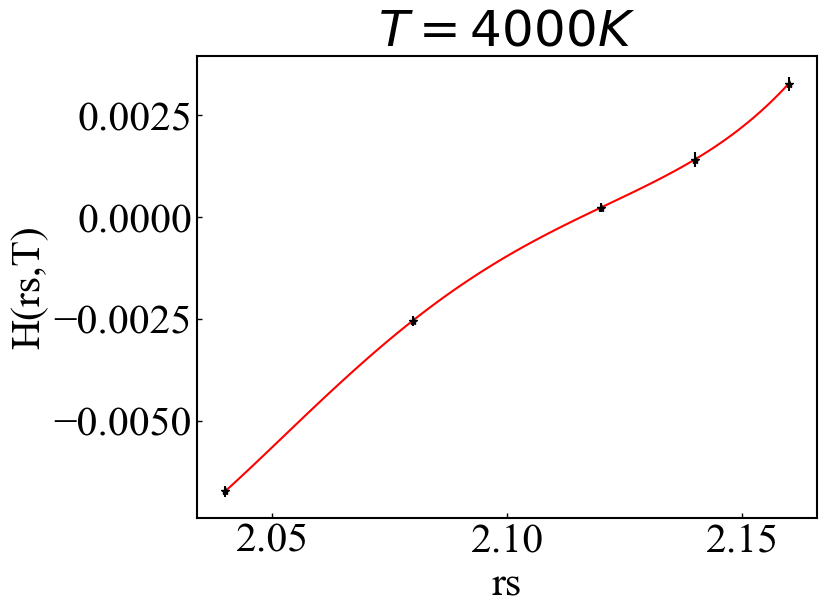

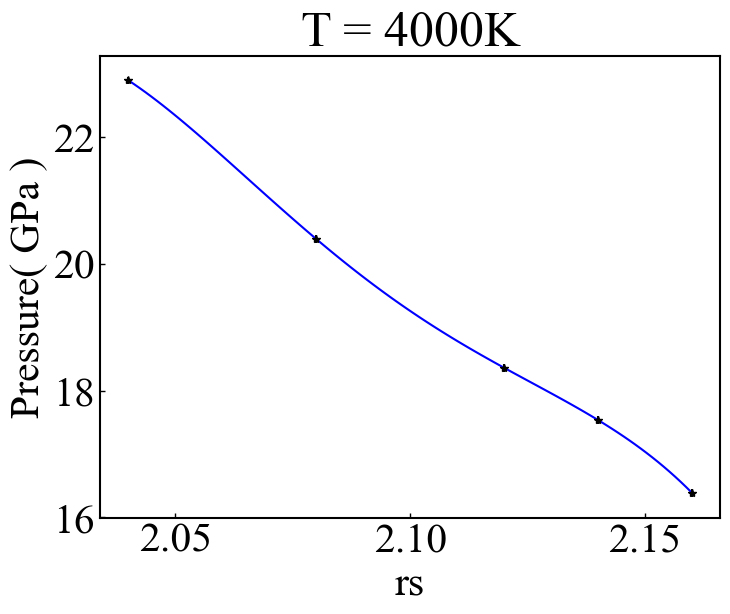

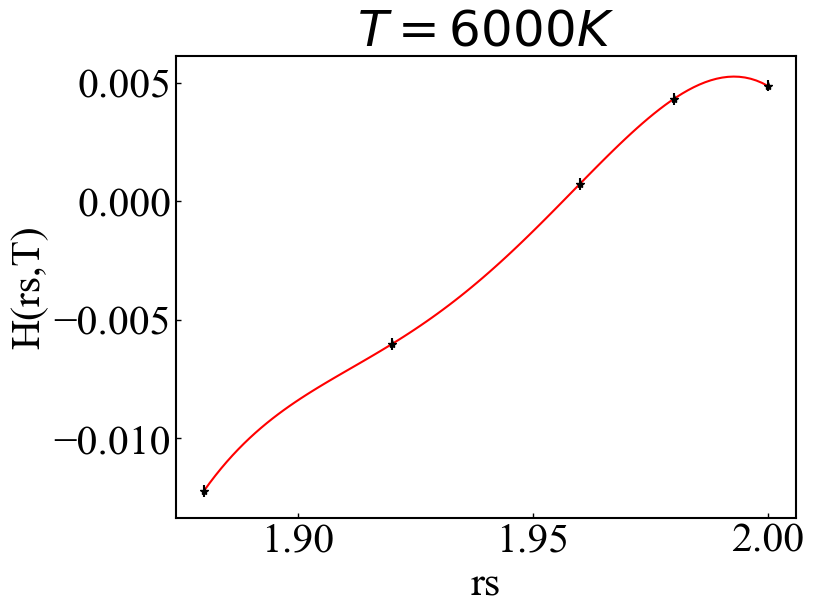

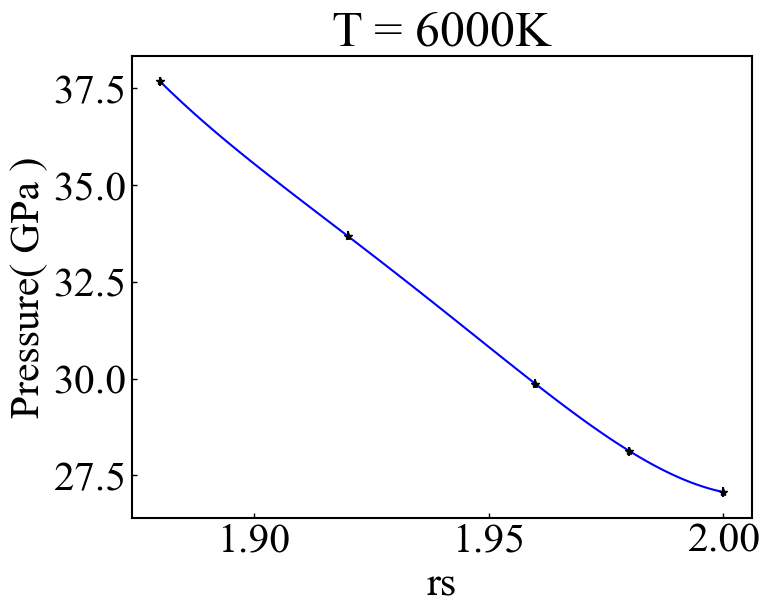

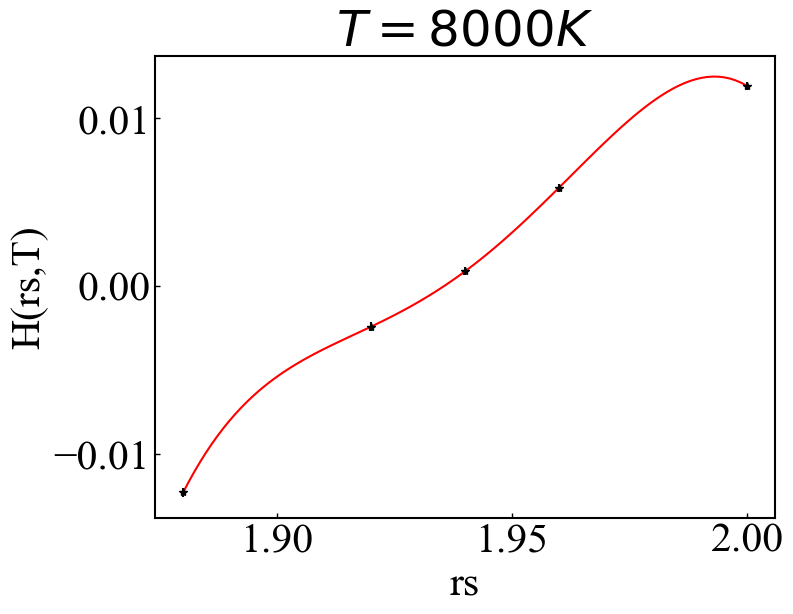

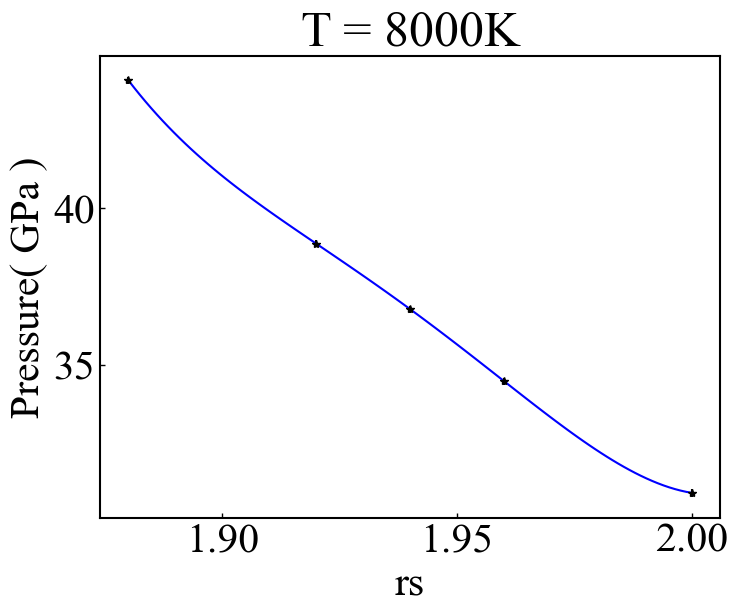

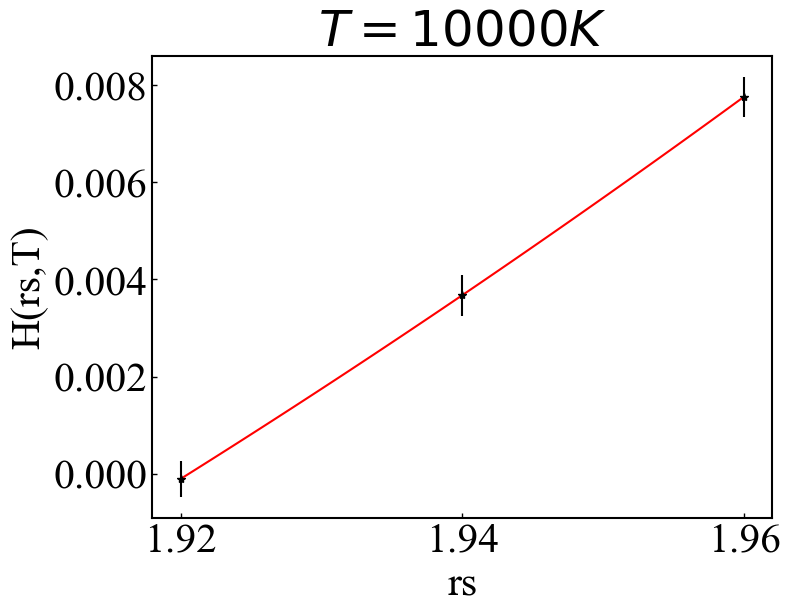

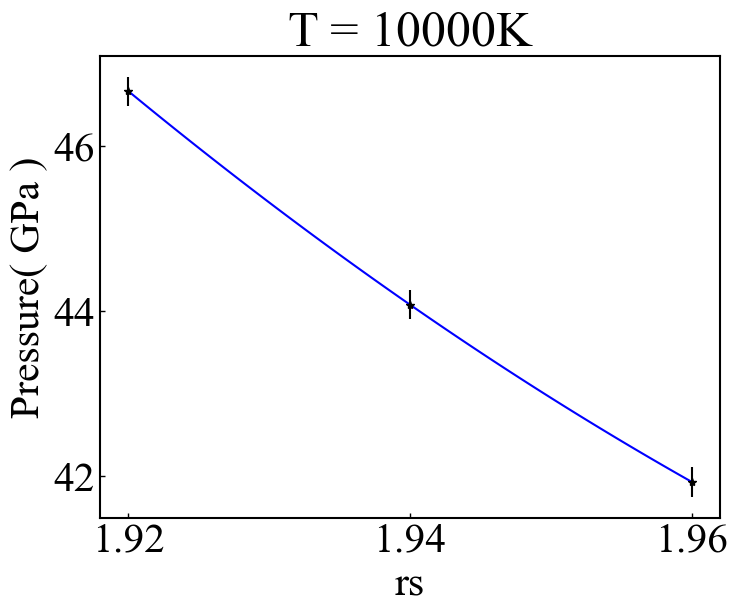

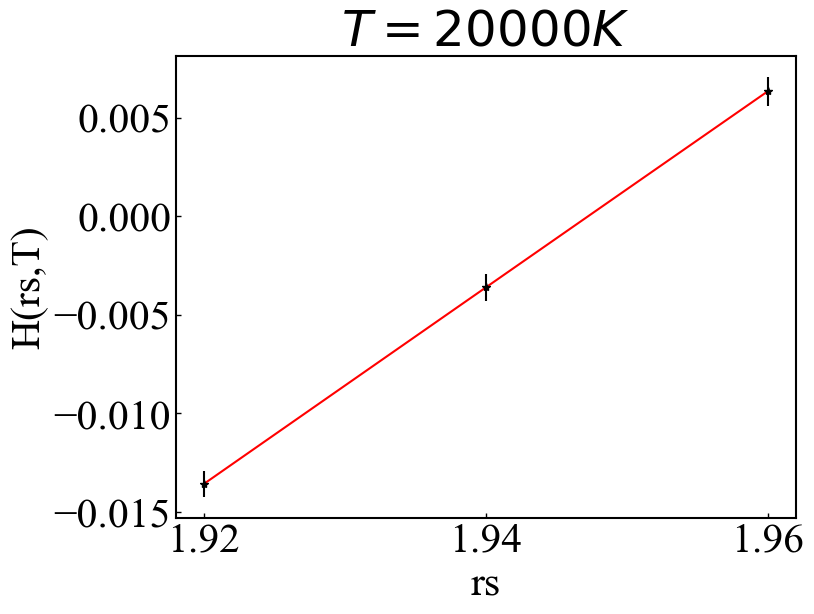

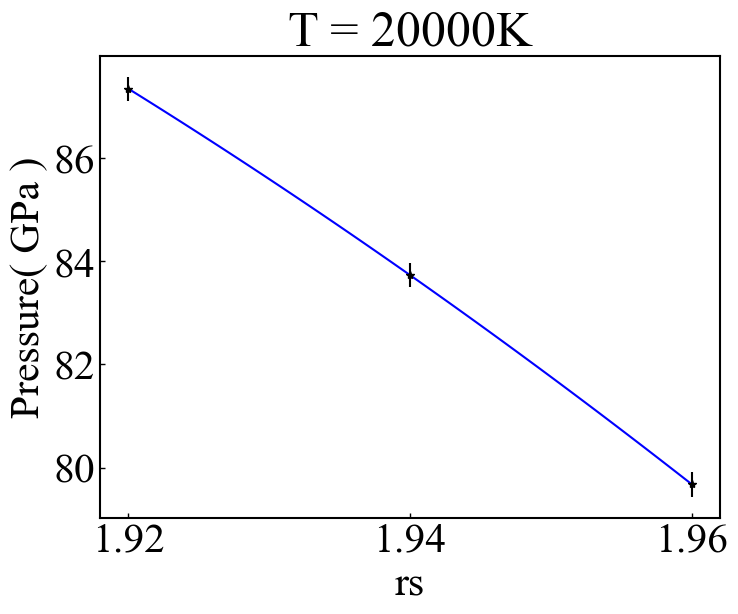

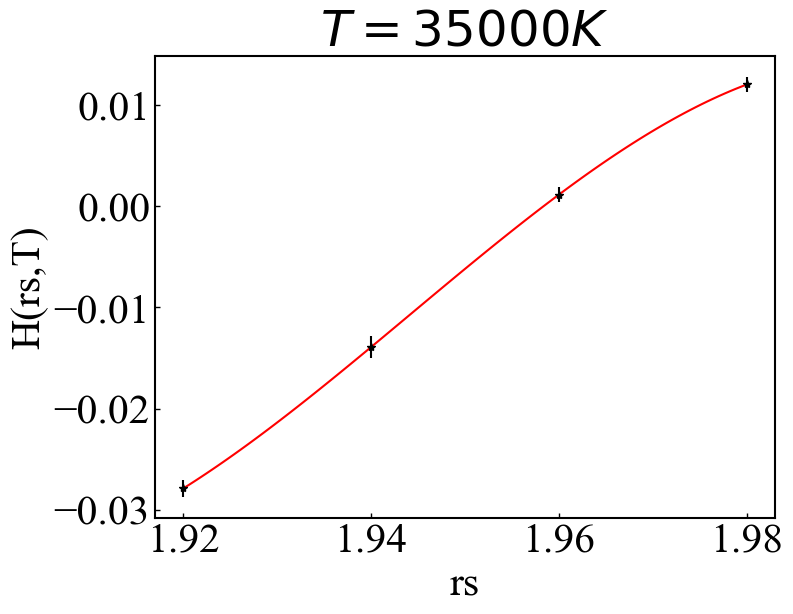

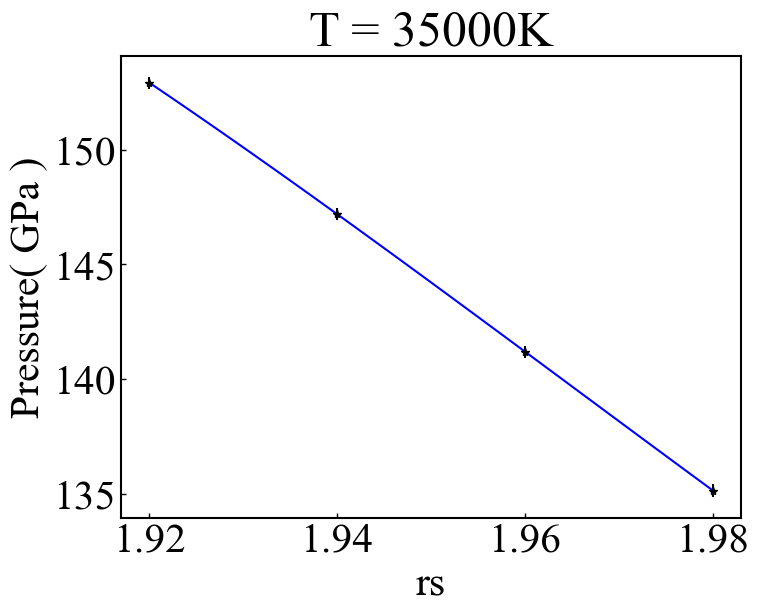

In [14]:
print('VMC HUGONIOT')
pressure_hug_vmc = []
density_hug_vmc = []
temperature_hug_vmc = [4000,6000,7000, 8000 ,10000 , 15000 , 20000, 35000]


for T in temperature_hug_vmc:
    Hug = get_hug(T,e0_vmc,root ="./simulations/vmc_pbe/",plot =True)
    pressure_hug_vmc.append(Hug[1])
    density_hug_vmc.append(rho_from_rs(Hug[0]))
p_hug_vmc = np.array(pressure_hug_vmc)
rho_hug_vmc = np.array(density_hug_vmc)   

print('DMC HUGONIOT')
pressure_hug_lrdmc = []
density_hug_lrdmc = []
temperature_hug_lrdmc = [4000,6000,7000, 8000 ,10000 , 15000 , 20000, 35000]
#temperature_hug_lrdmc = [8000, 10000 , 15000 , 20000, 35000]


for T in temperature_hug_lrdmc:
    #print(T)
    Hug = get_hug(T,e0_lrdmc_fsc,root ="./simulations/lrdmc_pbe_fsc/",plot =True)
    pressure_hug_lrdmc.append(Hug[1])
    density_hug_lrdmc.append(rho_from_rs(Hug[0]))
p_hug_lrdmc = np.array(pressure_hug_lrdmc)
rho_hug_lrdmc = np.array(density_hug_lrdmc)   

print('PBE HUGONIOT')
e0_pbe = -0.5805490133522
#e0 =  -0.583038561738
pressure_hug_pbe = []
density_hug_pbe = []
temperature_hug_pbe = [4000,6000,8000,10000, 20000,35000]#, 15000,20000,35000]
for T in temperature_hug_pbe:
    Hug = get_hug(T,e0_pbe,root ="./simulations/pbe/",plot =True)
    pressure_hug_pbe.append(Hug[1])
    density_hug_pbe.append(rho_from_rs(Hug[0]))
p_hug_pbe = np.array(pressure_hug_pbe)
rho_hug_pbe = np.array(density_hug_pbe) 


#p_hug_vmc = np.array([ufloat(x,y) for x,y in zip(pressure_hug_vmc,[1]*len(pressure_hug_vmc))])
#rho_hug_vmc = np.array([ufloat(x,y) for x,y in zip(rho_hug_vmc,[0.06*rho0]*len(rho_hug_vmc))])
#p_hug_lrdmc = np.array([ufloat(x,y) for x,y in zip(pressure_hug_lrdmc,[1]*len(pressure_hug_lrdmc))])
#rho_hug_lrdmc = np.array([ufloat(x,y) for x,y in zip(rho_hug_lrdmc,[0.06*rho0]*len(rho_hug_lrdmc))])

p_hug_vmc = np.array([ufloat(x,y) for x,y in zip(pressure_hug_vmc,[0.7,0.5,0.9,0.5,0.9,0.8,0.9,0.8])])
rho_hug_vmc = np.array([ufloat(x,y) for x,y in zip(rho_hug_vmc,np.array([0.15,0.1,0.15,0.08,0.08,0.05,0.05,0.03])*rho0)])
p_hug_lrdmc = np.array([ufloat(x,y) for x,y in zip(pressure_hug_lrdmc,[0.7,0.5,0.9,0.5,0.9,0.8,0.9,0.8])])
rho_hug_lrdmc = np.array([ufloat(x,y) for x,y in zip(rho_hug_lrdmc,np.array([0.15,0.1,0.15,0.08,0.08,0.05,0.05,0.03])*rho0)])

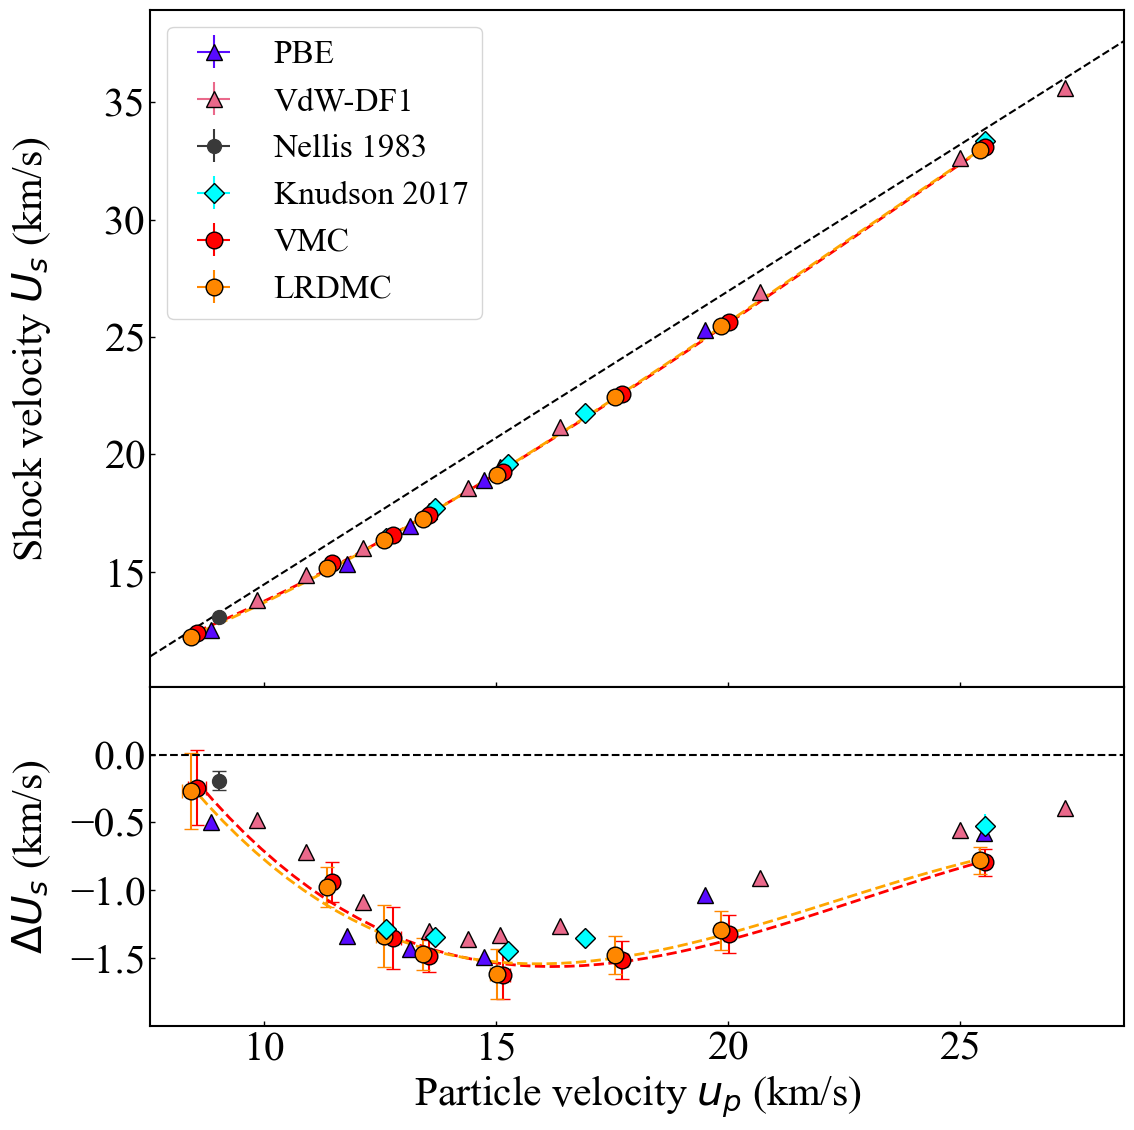

In [15]:
ushock_vmc = unumpy.sqrt(p_hug_vmc / ( 1 / rho0 - 1/ rho_hug_vmc)) / rho0
up_vmc = unumpy.sqrt(p_hug_vmc* ( 1 / rho0 - 1/ rho_hug_vmc))
ushock_lrdmc = unumpy.sqrt(p_hug_lrdmc / ( 1 / rho0 - 1/ rho_hug_lrdmc)) / rho0
up_lrdmc = unumpy.sqrt(p_hug_lrdmc* ( 1 / rho0 - 1/ rho_hug_lrdmc))
#ushock_vmcft = np.sqrt(pressure_hug_vmcft/ ( 1 / rho0 - 1/ rho_hug_vmcft)) / rho0
#up_vmcft = np.sqrt(pressure_hug_vmcft* ( 1 / rho0 - 1/ rho_hug_vmcft))
#ushock_dmcft = np.sqrt(pressure_hug_dmcft / ( 1 / rho0 - 1/ rho_hug_dmcft)) / rho0
#up_dmcft = np.sqrt(pressure_hug_dmcft* ( 1 / rho0 - 1/ rho_hug_dmcft))
ushock_pbe = np.sqrt(p_hug_pbe / ( 1 / rho0 - 1/ rho_hug_pbe)) / rho0
up_pbe = np.sqrt(p_hug_pbe* ( 1 / rho0 - 1/ rho_hug_pbe))
ushock_df1 = np.sqrt(p_df1 / ( 1 / rho0 - 1/ rho_df1 )) / rho0
up_df1 = np.sqrt(p_df1* ( 1 / rho0 - 1/ rho_df1 ))
exp_rho = [3.2427770749094464 ,4.29880694143167  ,4.393167028199567 ,4.533080260303688 ,4.503796095444686 ,4.273170731707317  ]
exp_p = [19.698756384498836,34.72017353579177,40.51388286334057,49.90455531453363,61.50650759219089, 142.29999999999998] 
exp_p = np.array([ufloat(x,y) for x,y in zip(exp_p,[0.1]*len(exp_rho))])
exp_rho = np.array([ufloat(x,y) for x,y in zip(exp_rho,[0.07]*len(exp_rho))])

ushock_exp = unumpy.sqrt(exp_p / ( 1 / rho0 - 1/ (rho0*exp_rho))) / rho0
up_exp = unumpy.sqrt(exp_p * ( 1 / rho0 - 1/ (rho0*exp_rho)))
#print(ushock_exp)
fig = plt.figure(figsize = (12,12))
gs = fig.add_gridspec(2, hspace=0.0,height_ratios=[2,1])
axs = gs.subplots(sharex=True, sharey=False)




axs[0].set_ylabel(r'Shock velocity $U_s$ (km/s) ')
axs[1].set_ylabel(r'$\Delta U_s$ (km/s)')
plt.xlabel(r'Particle velocity $u_p$ (km/s)')
axs[0].errorbar(unumpy.nominal_values(up_pbe),unumpy.nominal_values(ushock_pbe), xerr =unumpy.std_devs(up_pbe), yerr = unumpy.std_devs(ushock_pbe), fmt = '^' ,mec = 'k' ,color = '#580aff' ,ms= 12 ,label=  'PBE')
axs[0].errorbar(unumpy.nominal_values(up_df1),unumpy.nominal_values(ushock_df1), xerr =unumpy.std_devs(up_df1), yerr = unumpy.std_devs(ushock_df1), fmt = '^' ,mec = 'k' ,color = '#ea698b' ,ms= 12 ,label=  'VdW-DF1')
#axs[0].errorbar(unumpy.nominal_values(up_vmcft),unumpy.nominal_values(ushock_vmcft), xerr =unumpy.std_devs(up_vmcft), yerr = unumpy.std_devs(ushock_vmcft), fmt = '*' ,marker = 'o',fillstyle = 'none',color = 'r' ,ms= 12 ,mew = 2,label=  'FT-VMC')
#axs[0].errorbar(unumpy.nominal_values(up_dmcft),unumpy.nominal_values(ushock_dmcft), xerr =unumpy.std_devs(up_dmcft), yerr = unumpy.std_devs(ushock_dmcft), fmt = '*'  ,marker = 'o', fillstyle = 'none',color = 'orange' ,ms= 12 ,mew = 2,label=  'FT-DMC')
axs[0].errorbar(unumpy.nominal_values(up_exp)[0],unumpy.nominal_values(ushock_exp)[0], xerr =unumpy.std_devs(up_exp)[0], yerr = unumpy.std_devs(ushock_exp)[0], fmt = 'o' ,color = '#393939' ,ms= 10 ,label=  'Nellis 1983')
axs[0].errorbar(unumpy.nominal_values(up_exp)[1:],unumpy.nominal_values(ushock_exp)[1:], xerr =unumpy.std_devs(up_exp)[1:], yerr = unumpy.std_devs(ushock_exp)[1:], fmt = 'D' ,mec = 'k' ,color = 'cyan' ,ms= 10 ,label=  'Knudson 2017')
axs[0].errorbar(unumpy.nominal_values(up_vmc),unumpy.nominal_values(ushock_vmc), xerr =unumpy.std_devs(up_vmc), yerr = unumpy.std_devs(ushock_vmc), fmt = 'o' ,mec = 'k' ,color = '#ff0000' ,ms= 12 ,label=  'VMC')
axs[0].errorbar(unumpy.nominal_values(up_lrdmc),unumpy.nominal_values(ushock_lrdmc), xerr =unumpy.std_devs(up_lrdmc), yerr = unumpy.std_devs(ushock_lrdmc), fmt = 'o',mec = 'k'  ,color = '#ff8700' ,ms= 12 ,label=  'LRDMC')



#x = np.linspace(np.min(up_vmc) -1 , np.max(up_vmcft) + 1, 10)
x = np.linspace(np.min(unumpy.nominal_values(up_vmc)) -1 , np.max(unumpy.nominal_values(up_vmc)) + 3, 10)
axs[0].plot(x,1.969 + 1.249 * x,linestyle= '--', color = 'k')
#plt.xlim(np.min(up_vmc) -1 , np.max(up_vmcft) + 1)
#plt.xlim(np.min(up_vmc) -1 , np.max(up_vmc) + 1)
axs[1].set_ylim(-2.0,0.5)
axs[1].set_yticks([0,-0.5,-1,-1.5])
# Hide x labels and tick labels for all but bottom plot.
for ax in axs:
    ax.label_outer()
#plt.show()


axs[1].errorbar(unumpy.nominal_values(up_vmc),unumpy.nominal_values(ushock_vmc)-1.969 - 1.249 * unumpy.nominal_values(up_vmc), xerr =unumpy.std_devs(up_vmc), yerr = unumpy.std_devs(ushock_vmc), fmt = 'o' ,mec = 'k' ,color = '#ff0000' ,capsize = 5, ms= 12 ,label=  'VMC')
axs[1].errorbar(unumpy.nominal_values(up_pbe),unumpy.nominal_values(ushock_pbe)-1.969 - 1.249 * unumpy.nominal_values(up_pbe), xerr =unumpy.std_devs(up_pbe), yerr = unumpy.std_devs(ushock_pbe), fmt = '^' ,mec = 'k' ,color = '#580aff' ,ms= 12 ,label=  'PBE')
axs[1].errorbar(unumpy.nominal_values(up_df1),unumpy.nominal_values(ushock_df1)-1.969 - 1.249 * unumpy.nominal_values(up_df1), xerr =unumpy.std_devs(up_df1), yerr = unumpy.std_devs(ushock_df1), fmt = '^' ,mec = 'k' ,color = '#ea698b', ms= 12 ,label=  'VdW-DF1')
axs[1].errorbar(unumpy.nominal_values(up_lrdmc),unumpy.nominal_values(ushock_lrdmc)-1.969 - 1.249 * unumpy.nominal_values(up_lrdmc), xerr =unumpy.std_devs(up_lrdmc), yerr = unumpy.std_devs(ushock_lrdmc), fmt = 'o' ,mec = 'k' , capsize = 5, color = '#ff8700' ,ms= 12 ,label=  'LRDMC')
#axs[1].errorbar(unumpy.nominal_values(up_vmcft),unumpy.nominal_values(ushock_vmcft)-1.969 - 1.249 * unumpy.nominal_values(up_vmcft) , xerr =unumpy.std_devs(up_vmcft), yerr = unumpy.std_devs(ushock_vmcft), fmt = 'o' ,fillstyle = 'none',color = 'r' ,ms= 12,mew = 2 ,label=  'FT-VMC')
#axs[1].errorbar(unumpy.nominal_values(up_dmcft),unumpy.nominal_values(ushock_dmcft)-1.969 - 1.249 * unumpy.nominal_values(up_dmcft) , xerr =unumpy.std_devs(up_dmcft), yerr = unumpy.std_devs(ushock_dmcft), fmt = 'o' , fillstyle = 'none',color = 'orange' ,ms= 12,mew = 2 ,label=  'FT-DMC')
axs[1].errorbar(unumpy.nominal_values(up_exp)[0],unumpy.nominal_values(ushock_exp)[0]-1.969 - 1.249 * unumpy.nominal_values(up_exp)[0], xerr =unumpy.std_devs(up_exp)[0], yerr = unumpy.std_devs(ushock_exp)[0], fmt = 'o' ,color = '#393939' , capsize= 5,ms= 10 ,label=  'Nellis 1983')

axs[1].errorbar(unumpy.nominal_values(up_exp)[1:],unumpy.nominal_values(ushock_exp)[1:]-1.969 - 1.249 * unumpy.nominal_values(up_exp)[1:], xerr =unumpy.std_devs(up_exp)[1:], yerr = unumpy.std_devs(ushock_exp)[1:], fmt = 'D',mec = 'k' ,color = 'cyan' ,ms= 10 ,label=  'Knudson 2017')

#fit Delta U_s
x = np.linspace(np.min(up_pbe) , np.max(up_pbe), 50)
pbe_fit = spline(up_pbe,ushock_pbe,k=3)
#axs[0].plot(x,pbe_fit(x),lw = 2 , linestyle = '--', color = 'b')
#axs[1].plot(x,pbe_fit(x)-(1.969 + 1.249 * x),lw = 2 , linestyle = '--', color = 'b')

#x = np.linspace(np.min(up_vmc) , np.max(up_vmcft), 50)
x = np.linspace(np.min(unumpy.nominal_values(up_vmc)) , np.max(unumpy.nominal_values(up_vmc)), 50)
#vmc_fit = spline(np.concatenate((up_vmc,up_vmcft),axis = None),np.concatenate((ushock_vmc,ushock_vmcft),axis = None),k=3)
vmc_fit = spline(unumpy.nominal_values(up_vmc),unumpy.nominal_values(ushock_vmc),k=3)
axs[0].plot(x,vmc_fit(x),lw = 2 , linestyle = '--', color = 'r')
axs[1].plot(x,vmc_fit(x)-(1.969 + 1.249 * x),lw = 2 , linestyle = '--', color = 'r')

x = np.linspace(np.min(unumpy.nominal_values(up_lrdmc)) , np.max(unumpy.nominal_values(up_lrdmc)), 50)
#dmc_fit = spline(np.concatenate((up_dmc,up_dmcft),axis = None),np.concatenate((ushock_dmc,ushock_dmcft),axis = None),k=3)
dmc_fit = spline(unumpy.nominal_values(up_lrdmc),unumpy.nominal_values(ushock_lrdmc),k=3)
axs[0].plot(x,dmc_fit(x),lw = 2 , linestyle = '--', color = 'orange')
axs[1].plot(x,dmc_fit(x)-(1.969 + 1.249 * x),lw = 2 , linestyle = '--', color = 'orange')
axs[0].get_yaxis().set_label_coords(-0.1,0.5)
axs[1].get_yaxis().set_label_coords(-0.1,0.5)
axs[0].set_xlim(np.min(unumpy.nominal_values(up_vmc)) -1 , np.max(unumpy.nominal_values(up_vmc)) + 3)
axs[1].hlines(0, 7.5, 29 , colors= 'k' , ls = '--')
x = np.linspace(np.min(unumpy.nominal_values(up_exp)), np.max(unumpy.nominal_values(up_exp)), 50)
exp_fit = spline(unumpy.nominal_values(up_exp),unumpy.nominal_values(ushock_exp),k=3)
#axs[0].plot(x,exp_fit(x),lw = 2 , linestyle = '--', color = 'cyan')
#axs[1].plot(x,exp_fit(x)-(1.969 + 1.249 * x),lw = 2 , linestyle = '--', color = 'cyan')
#plt.annotate('(b)', (150,750), xycoords = 'figure points', fontsize = 50)
axs[0].legend(fontsize = 24)
plt.tight_layout()
#plt.savefig('Hugoniot_shockvelocity.pdf',format ='pdf', bbox_inches='tight')
plt.show()

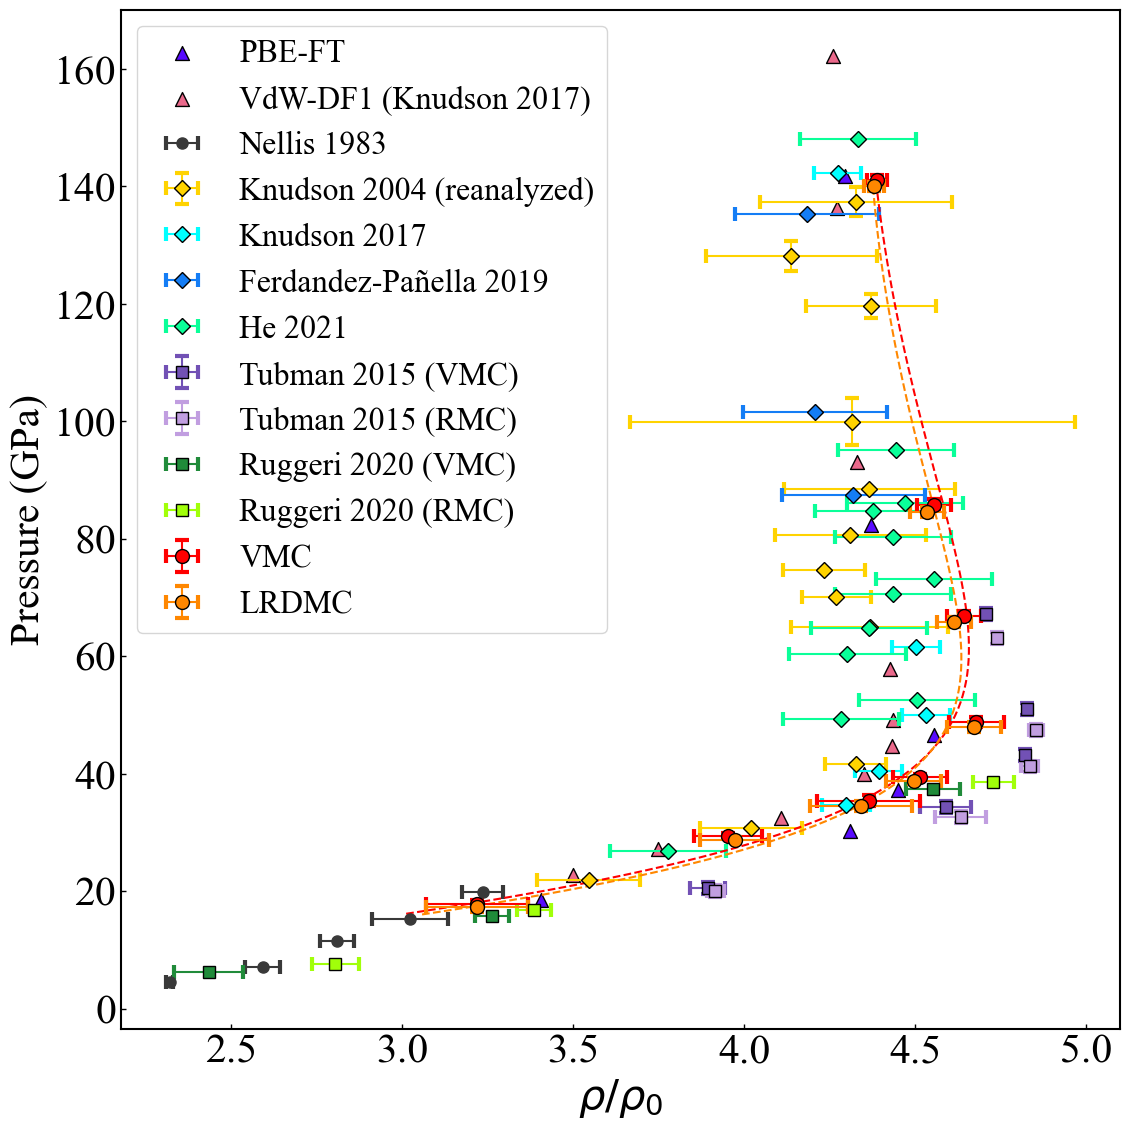

In [26]:
#plot hugoniot for different functionals + ref data + experimental values

plt.figure(figsize = (12,12))

#EXPERIMENT 
#he2021
exp_rho_he = [3.7778 ,4.2844  ,4.3022  ,4.3644  ,4.4356  ,4.4356  ,4.3778  ,4.4444  ,4.4711  ,4.5556  ,4.5067  ,4.3333 ]
exp_p_he = [26.81 , 49.3090 ,60.2738 ,64.7799 ,70.5749 ,80.2523 ,84.7778 ,95.0896 ,86.0530 ,73.1362 ,52.4989 ,148.0108]

#knudson 2017 
exp_rho = [4.29880694143167  ,4.393167028199567 ,4.533080260303688 ,4.503796095444686 ,4.273170731707317  ]
exp_p = [34.72017353579177,40.51388286334057,49.90455531453363,61.50650759219089, 142.29999999999998] 
#knudson Al 2004 reanalyzed
exp_al_rho = [3.545340023088322 ,4.020234783435634 ,4.32589623737395  ,4.367773012183363 ,4.270067158366869 ,4.232563682478998 ,4.310548161059703 ,4.365721786925365 ,4.316707253801808,4.370731707317073,4.138211382113822,4.326829268292682 ]
exp_al_p = [21.916463129105622,30.738320715810218,41.54668884814795,64.92350639142049,70.01133951991218,74.70362563694518,80.60227055227796,88.39728766387834,99.88126005900885,119.59933222036729,128.1135225375626,137.32888146911517]
exp_al_rho_err = [0.15, 0.15, 0.09 , 0.23, 0.1, 0.12, 0.22, 0.25, 0.65, 0.19, 0.25, 0.28]
exp_al_p_err = [0,0,0,0,0,0,0,0,4,2,2.5,2.5]
#panella 2019 
exp_pan_rho = np.array([4.474922459273001 ,4.359038929793032 ,4.3350049278219025]) * rho0 / 0.173
exp_pan_p = [ 87.44680851063822,101.48936170212755,135.31914893617005]
#gas gun

rho_gasgun = [3.2356  ,3.0222  ,2.8089  ,2.5911  ,2.3200]
p_gasgun = [ 19.8007 , 15.3190 , 11.4824 , 7.0014 , 4.4645]

plt.errorbar(rho_gasgun , p_gasgun, xerr = [0.06, 0.11, 0.05 ,0.05, 0.01] , color = '#393939',ms = 8  , fmt = 'o', capsize = 5,capthick=3, label = 'Nellis 1983')
plt.errorbar(exp_al_rho , exp_al_p , xerr = exp_al_rho_err, yerr = exp_al_p_err ,fmt ='D', color = '#ffd300', ms = 8  ,mec = 'k', capthick=3,capsize = 5, label = 'Knudson 2004 (reanalyzed)')
plt.errorbar(exp_rho , exp_p , xerr = 0.07 * np.ones(len(exp_rho)) ,fmt ='D',color = 'cyan', ms = 8 , capsize = 5,capthick=3, mec = 'k', label ='Knudson 2017' )
#gas gun reanalyzed
plt.errorbar(exp_pan_rho , exp_pan_p , xerr = 0.21 * np.ones(len(exp_pan_rho)) ,fmt ='D' ,color = '#147df5', ms =8 , mec = 'k',capsize = 5 ,capthick=3, label = 'Ferdandez-Pañella 2019')
plt.errorbar(exp_rho_he , exp_p_he , xerr = 0.17 * np.ones(len(exp_p_he)) ,fmt ='D' ,color = '#0aff99', ms = 8 , mec = 'k',capsize = 5 ,capthick=3, label = 'He 2021')



#plot_fit_hug(exp_rho,exp_p, c = 'cyan', kvalue = 1)

rho_exp_all = [2.3183213920163768,2.5870010235414536,2.8070624360286596,3.032241555783009 ,3.2471852610030707,3.5491299897645856,4.019959058341863 ,4.296315250767656 ,4.3909928352098255,4.327021494370522 ,4.534288638689866 ]
p_exp_all = [4.088050314465413, 6.792452830188687, 10.314465408805042,14.276729559748432, 19.748427672955977, 21.82389937106919,30.691823899371077,34.9056603773585, 40.62893081761007,41.383647798742146,50.25157232704404]

#ruggeri 2020
rho_vmc_ruggeri = [2.4334698055271238,3.2625383828045034,4.552200614124872 ]
p_vmc_ruggeri = [6.289308176100633,15.723270440251575,37.421383647798756]

rho_dmc_ruggeri = [2.8045035823950872,3.385363357215967 ,4.728761514841351 ]
p_dmc_ruggeri = [7.547169811320764,16.729559748427683,38.49056603773586]

#tubman 2015
rho_vmc_tubman = [ 3.8929  , 4.5900  , 4.8223  , 4.8269  , 4.7062 ]
p_vmc_tubman = [ 20.5066 ,34.2581 ,43.1604 ,51.0495 ,67.1170]

rho_dmc_tubman = [3.9157 ,4.6333 ,4.8360 ,4.8542 ,4.7403  ]
p_dmc_tubman = [ 20.0000 ,32.5935 ,41.2063 ,47.4306 ,63.0639]

#knudson PBE 
rho_pbe_ref1  = [3.2481040086673856 ,4.515709642470204  ,4.527085590465871  ,4.4539544962080155] 
p_pbe_ref1 = [16.409642470205895, 38.194149512459774, 45.694907908992825, 54.890032502708934]
#tubman PBE
rho_pbe_ref2 = [3.8646112505242805 ,4.421362204892336  ,4.6718651586348106 ,4.6883179662896595 ,4.62868009298424   ]
p_pbe_ref2 = [24.858895705521476, 39.14110429447853, 44.66257668711657, 50.625766871165645, 66.60122699386503]
#Holst PBE 
rho_pbe_ref3 = [3.783399327499307 ,3.94567530870341  ,4.08014132466997  ,4.284166376387121 ,4.474383126346246 ,4.544021781629215 ,4.585878907221918 ,4.590599208070008 ,4.576540673495938 ,4.586134827147418 ,4.558563720507006 ,4.521751061001359 ,4.489584769920878 ,4.471249529036248   ]
p_pbe_ref3 = [22.28220858895706, 23.607361963190186, 24.932515337423318, 27.14110429447853, 31.852760736196323, 34.79754601226995, 38.47852760736197, 40.68711656441718, 36.7116564417178, 45.104294478527606, 51.288343558282214, 58.20858895705521, 65.42331288343559, 70.7239263803681]




#DFT
plt.scatter(unumpy.nominal_values(rho_hug_pbe)/rho0,unumpy.nominal_values(p_hug_pbe),marker = '^',edgecolors = 'k', color = '#580aff' ,s= 100 ,label=  'PBE-FT')
#plt.errorbar(unumpy.nominal_values(rho_pbe_ref1),unumpy.nominal_values(p_pbe_ref1), xerr =unumpy.std_devs(rho_pbe_ref1), yerr = unumpy.std_devs(p_pbe_ref1), fmt = '^' , color = 'b' ,fillstyle='none',ms= 12 ,label=  'PBE (Ref. Knudson)')
#plt.errorbar(unumpy.nominal_values(rho_pbe_ref2),unumpy.nominal_values(p_pbe_ref2), xerr =unumpy.std_devs(rho_pbe_ref2), yerr = unumpy.std_devs(p_pbe_ref2), fmt = '^' , color = 'violet' ,fillstyle='none',ms= 12 ,label=  'PBE (Ref. Tubman)')
#plt.errorbar(unumpy.nominal_values(rho_pbe_ref3),unumpy.nominal_values(p_pbe_ref3), xerr =unumpy.std_devs(rho_pbe_ref3), yerr = unumpy.std_devs(p_pbe_ref3), fmt = '^' , color = 'pink' ,fillstyle='none',ms= 12 ,label=  'PBE (Ref. Holst)')
plt.scatter(unumpy.nominal_values(rho_df1)/rho0,unumpy.nominal_values(p_df1), marker = '^' ,edgecolors = 'k', color = '#ea698b' ,s= 100 ,label=  'VdW-DF1 (Knudson 2017)')





#plt.errorbar(unumpy.nominal_values(rho_hug_vmcfsc)/rho0,unumpy.nominal_values(p_hug_vmcfsc), xerr =unumpy.std_devs(rho_hug_vmcfsc), yerr = unumpy.std_devs(p_hug_vmcfsc), fmt = '^' ,color = 'green', fillstyle='none',ms= 18 ,label=  'VMC + finite size corrections')
#plt.errorbar(unumpy.nominal_values(rho_hug_dmcft)/rho0,unumpy.nominal_values(p_hug_dmcft), xerr =0.01* unumpy.nominal_values(rho_hug_dmcft)/rho0, yerr = 0.02 * unumpy.nominal_values(p_hug_dmcft), fmt = 'o' ,color = 'orange',fillstyle='none' ,ms= 10 ,capsize = 5,capthick= 3,label=  'LRDMC-FT')
#print('VMC')
#print(rho_hug_vmcft / rho0)
#print(p_hug_vmcft)

#plt.scatter(rho_pbe_ref , p_pbe_ref , color = 'k', s = 25 , label ='PBE Ref.' )


##plt.scatter(rho_pbeft_ref , p_pbeft_ref , color = 'grey', s = 25 , label ='FT-PBE Ref.' )
#plt.xlim(2.4,4.8)
#plt.xlabel(r'$\rho / \rho_0$')
#plt.ylabel('Pressure (GPa)')







#plt.figure(figsize = (12,12))
#plt.ylim(0,60)
#plt.xlabel(r'$\rho / \rho_0$')
#plt.ylabel('Pressure (GPa)')

#plt.errorbar(unumpy.nominal_values(rho_hug_pbe)/rho0,unumpy.nominal_values(p_hug_pbe), xerr =unumpy.std_devs(rho_hug_pbe), yerr = unumpy.std_devs(p_hug_pbe), fmt = '*' ,color = 'b' ,ms= 15 ,label=  'PBE')
#plt.errorbar(unumpy.nominal_values(rho_hug_vmc)/rho0,unumpy.nominal_values(p_hug_vmc), xerr =unumpy.std_devs(rho_hug_vmc), yerr = unumpy.std_devs(p_hug_vmc), fmt = '*' ,color = 'r' ,ms= 15 ,label=  'VMC')
#plt.errorbar(unumpy.nominal_values(rho_hug_dmc)/rho0,unumpy.nominal_values(p_hug_dmc), xerr =unumpy.std_devs(rho_hug_dmc), yerr = unumpy.std_devs(p_hug_dmc), fmt = '*' ,color = 'y' ,ms= 15 ,label=  'DMC')
#plt.errorbar(unumpy.nominal_values(rho_hug_vmc54)/rho0,unumpy.nominal_values(p_hug_vmc54), xerr =unumpy.std_devs(rho_hug_vmc54), yerr = unumpy.std_devs(p_hug_vmc54), fmt = '*' ,color = 'm' ,ms= 15 ,label=  'VMC (54 D)')


#plt.errorbar(unumpy.nominal_values(rho_hug_vmcft)/rho0,unumpy.nominal_values(p_hug_vmcft), xerr =unumpy.std_devs(rho_hug_vmcft), yerr = unumpy.std_devs(p_hug_vmcft), fmt = 'o' ,color = 'r' ,ms= 15 ,label=  'VMC-FT')
plt.errorbar(rho_vmc_tubman,p_vmc_tubman,xerr = [0.05,0.075,0,0,0], yerr = [1, 1,1,1,1],  color = '#7251b5', fmt = 's', ms =8 ,mec = 'k' ,capsize = 5,capthick=3,label = 'Tubman 2015 (VMC)')
plt.errorbar(rho_dmc_tubman,p_dmc_tubman, xerr = [0.025,0.075,0.025,0.02,0], yerr = [1 ,1, 1, 1, 1 ], color = '#c19ee0', ms =8 , fmt = 's' ,mec = 'k', capsize = 5,capthick=3,label = 'Tubman 2015 (RMC)')
plt.errorbar(rho_vmc_ruggeri,p_vmc_ruggeri,xerr = [0.1,0.05,0.08],  color = '#208b3a', fmt = 's', ms =8 ,mec = 'k' ,capsize = 5,capthick=3,label = 'Ruggeri 2020 (VMC)')
plt.errorbar(rho_dmc_ruggeri,p_dmc_ruggeri, xerr = [0.07,0.05,0.06], color = '#a1ff0a', ms =8 , fmt = 's' ,mec = 'k', capsize = 5,capthick=3,label = 'Ruggeri 2020 (RMC)')
u_exp = np.linspace(unumpy.nominal_values(up_exp)[0] -1,unumpy.nominal_values(up_exp)[-1],100)
u_vmc = np.linspace(unumpy.nominal_values(up_exp)[0] -1,unumpy.nominal_values(up_vmc[-1]),100)
u_dmc = np.linspace(unumpy.nominal_values(up_exp)[0] -1,unumpy.nominal_values(up_lrdmc[-1]),100)
#plt.plot(1 / ( 1 - u_exp / exp_fit(u_exp) ), rho0*u_exp * exp_fit(u_exp), linestyle = '--', color = 'cyan')
plt.plot(1 / ( 1 - unumpy.nominal_values(u_vmc) / vmc_fit(u_vmc) ), rho0*u_vmc * vmc_fit(unumpy.nominal_values(u_vmc)), linestyle = '--', color = '#ff0000')
plt.plot(1 / ( 1 - unumpy.nominal_values(u_dmc) / dmc_fit(u_dmc) ), rho0*u_dmc * dmc_fit(unumpy.nominal_values(u_dmc)), linestyle = '--', color = '#ff8700')

# QMC results
plt.errorbar(unumpy.nominal_values(rho_hug_vmc)/rho0,unumpy.nominal_values(p_hug_vmc), xerr = unumpy.std_devs(rho_hug_vmc) / rho0, yerr = unumpy.std_devs(p_hug_vmc), fmt = 'o', mec = 'k' ,color = '#ff0000' ,ms= 10 ,capsize = 5, capthick= 3,label=  'VMC')
#plt.errorbar(unumpy.nominal_values(rho_hug_vmcft)/rho0,unumpy.nominal_values(p_hug_vmcft), xerr = 0.01 * unumpy.nominal_values(rho_hug_vmcft) / rho0, yerr = 0.02 * unumpy.nominal_values(p_hug_vmcft), fmt = 'o' ,color = 'r', fillstyle='none',ms= 10 ,capsize = 5,capthick = 3,  label=  'VMC-FT')
plt.errorbar(unumpy.nominal_values(rho_hug_lrdmc)/rho0,unumpy.nominal_values(p_hug_lrdmc), xerr =unumpy.std_devs(rho_hug_lrdmc)/rho0, yerr = unumpy.std_devs(p_hug_lrdmc), fmt = 'o', mec = 'k' ,color = '#ff8700' ,ms= 10 ,capsize = 5,capthick =3, label=  'LRDMC')

#plt.scatter(rho_pbe_ref , p_pbe_ref , color = 'k', s = 25 , label ='PBE Ref.' )
#plt.errorbar(exp_rho , exp_p , xerr = 0.07 * np.ones(len(exp_rho)) ,fmt ='*', color = 'cyan', ms = 10 , label ='Experiment' )
#plt.errorbar(rho_exp_all , p_exp_all , xerr = 0.07 * np.ones(len(rho_exp_all)) ,fmt ='^', color = 'cyan', ms = 10 , label ='Experiment' )


#plt.legend(fontsize =2)
#plt.tight_layout()
#plt.savefig('hugoniot_detail.pdf', format = 'pdf')
#plt.show()
#
plt.xlabel(r'$\rho / \rho_0$')
plt.ylabel('Pressure (GPa)')
plt.legend( loc = 'upper left', fontsize = 23)
#plt.annotate('(a)', (700,735), xycoords = 'figure points', fontsize = 50)
plt.tight_layout()
#plt.savefig('Hugoniot.pdf',format ='pdf', bbox_inches='tight')
plt.show()